Problem Statement
-----------------

Email communication is widely used for personal and professional purposes. However, a large portion of emails received daily are spam messages, which may include advertisements, phishing attempts, or malicious links. These spam messages not only waste users’ time but also pose serious cybersecurity risks such as data theft, malware distribution, and financial fraud.

Traditional rule-based spam filters often fail to detect newly generated spam patterns. Therefore, there is a need for an intelligent system that can automatically classify messages as spam or legitimate (ham) using data-driven techniques.

In this project, we aim to develop a Machine Learning–based spam detection system using the SMS Spam Collection dataset. Multiple machine learning and deep learning models will be trained and evaluated on the same dataset, including Logistic Regression, Decision Tree, Random Forest, and Deep Neural Networks.

The models will be compared based on various evaluation metrics such as Accuracy, Precision, Recall, F1-Score, ROC Curve, and AUC Score. Additionally, model complexity will be analyzed through parameter count and computational cost (MAC values) to determine the most efficient and effective model for spam detection.

The final objective is to identify the best performing model for spam classification and demonstrate how machine learning can be applied to solve real-world cybersecurity problems.

First, import essential libraries

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

Load the dataset and get the information about the data

In [44]:
# read the data
data = pd.read_csv('spam.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


It has 5572 samples and 5 features

 - Now see the head of the dataset

In [45]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Remove Unnecessary Columns
The dataset contains extra unnamed columns that are not needed for analysis.  
We drop `Unnamed: 2`, `Unnamed: 3`, and `Unnamed: 4` to keep only relevant features.

In [46]:
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


Now , read the columns

In [47]:
data['v1'].unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

Label Encoding
--------------

Machine learning models require numerical input rather than categorical text labels. Therefore, the target variable (v1) containing the labels ham and spam is converted into numerical form.

In this step:

ham → 0 (represents a normal message)

spam → 1 (represents a spam message)

The map() function is used to perform this conversion. This process is known as label encoding, which prepares the target variable for training machine learning models.

Finally, data.head() is used to display the first few rows of the dataset to verify that the label transformation has been applied correctly.

In [48]:
data['v1'] = data['v1'].map({'ham':0, 'spam':1})
data.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Column Renaming and Data Preview
--------------------------------

The original dataset contains column names that are not descriptive for the analysis. To improve readability and make the dataset easier to work with, the columns are renamed.

v1 → label (indicates whether the message is spam or ham)

v2 → message (contains the actual SMS text)

After renaming the columns, the head() function is used to display the first few rows of the dataset. This helps verify that the dataset has been loaded and formatted correctly before proceeding with further preprocessing and model training.

In [49]:
data.columns = ['label','message']
data.head()


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Train–Test Data Split
---------------------

To evaluate the performance of the machine learning models fairly, the dataset is divided into training and testing sets.

The train_test_split() function from sklearn.model_selection is used for this purpose.

X represents the input feature (SMS message text).

y represents the target label (spam or ham).

The dataset is split so that:

75% of the data is used for training the model

25% of the data is used for testing the model

The parameter random_state=42 ensures reproducibility, meaning the same split will occur every time the code is executed.

The training data (X_train, y_train) is used to train the machine learning models, while the testing data (X_test, y_test) is used to evaluate how well the trained model performs on unseen data.

In [50]:
from sklearn.model_selection import train_test_split
X = data['message']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

TF-IDF Feature Extraction
-------------------------

Machine learning models cannot process raw text directly. Therefore, the SMS messages are converted into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency).

TF-IDF represents each message based on the importance of words in the dataset. Words that appear frequently in a specific message but are rare across the dataset receive higher weights, making them more informative for classification.

In this step, the TfidfVectorizer from sklearn.feature_extraction.text is used to transform the text messages into a sparse numerical matrix.

fit_transform() is applied to the training data to learn the vocabulary and create feature vectors.

transform() is applied to the test data using the same learned vocabulary to ensure consistency between training and testing features.

This vectorized representation is then used as input for machine learning models such as Logistic Regression, Decision Tree, and Random Forest.

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test) 

### Train Logistic Regression Model

Logistic Regression (LR) is a commonly used machine learning algorithm for binary classification, which makes it suitable for detecting whether an SMS message is spam or ham.

In this step:

The Logistic Regression model is initialized using LogisticRegression() from sklearn.linear_model.

X_train contains the input features extracted from the SMS messages (using TF-IDF or Count Vectorizer).

y_train contains the corresponding labels (spam or ham).

The fit() method trains the model by learning the optimal weights that separate spam and ham messages in the training data.

Once trained, the model can be used to predict labels on unseen test data and evaluate its performance using metrics such as accuracy, precision, recall, F1 score, ROC curve, and AUC.

In [52]:
from sklearn.linear_model import LogisticRegression
LoR = LogisticRegression()
LoR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Logistic Regression Prediction

After training the Logistic Regression model, it is used to make predictions on the test dataset.

X_test contains the unseen SMS messages that were not used during training.

The predict() function generates predicted labels for each message.

The predictions are stored in y_pred_LoR.

These predicted labels represent whether the model classifies each SMS message as spam or ham.
The predictions will later be used to evaluate the model’s performance using metrics such as accuracy, precision, recall, F1-score, ROC curve, and AUC score.

In [53]:
y_pred_LoR = LoR.predict(X_test)
y_pred_LoR

array([0, 0, 0, ..., 0, 0, 0], shape=(1393,))

### Train Decision Tree Model

Decision Tree (DT) is a supervised machine learning algorithm used for classification and regression tasks. In this project, it is used to classify SMS messages as spam or ham.

In this step:

The Decision Tree model is initialized using DecisionTreeClassifier() from sklearn.tree.

X_train contains the input features extracted from SMS messages (after text vectorization such as TF-IDF or Count Vectorizer).

y_train contains the corresponding labels (spam or ham).

The fit() method trains the model by learning decision rules from the training data.

The Decision Tree works by splitting the data into branches based on feature values, creating a tree-like structure where each decision helps classify the message as spam or ham.

After training, the model will be used to predict labels for unseen test data (X_test) and its performance will be evaluated using metrics such as accuracy, precision, recall, F1 score, ROC curve, and AUC.

In [54]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Decision Tree Prediction

After training the Decision Tree model, it is used to make predictions on the test dataset.

X_test contains the SMS messages that were not used during training.

The predict() function applies the trained Decision Tree model to classify each message.

The predicted labels are stored in y_pred_DT.

These predictions indicate whether each SMS message is classified as spam or ham by the Decision Tree model.

The predicted results will later be compared with the true labels (y_test) to evaluate the model’s performance using metrics such as accuracy, precision, recall, F1 score, ROC curve, and AUC score.

In [55]:
y_pred_DT = DT.predict(X_test)
y_pred_DT

array([0, 0, 0, ..., 0, 0, 0], shape=(1393,))

### Train Random Forest Model

Random Forest (RF) is an ensemble machine learning algorithm that combines multiple Decision Trees to improve classification performance and reduce overfitting. In this project, it is used to classify SMS messages as spam or ham.

In this step:

The Random Forest model is initialized using RandomForestClassifier() from sklearn.ensemble.

X_train contains the input features extracted from SMS messages after text vectorization (such as TF-IDF or Count Vectorizer).

y_train contains the corresponding labels (spam or ham).

The fit() method trains the model by constructing multiple decision trees using different subsets of the training data.

Random Forest works by aggregating the predictions of multiple decision trees and selecting the final prediction based on majority voting.

After training, the model can be used to predict labels for unseen test data (X_test), and its performance will be evaluated using metrics such as accuracy, precision, recall, F1 score, ROC curve, and AUC score.

In [56]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()
RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Random Forest Prediction

After training the Random Forest model, it is used to make predictions on the test dataset.

X_test contains the SMS messages that were not used during the training phase.

The predict() function applies the trained Random Forest model to classify each message.

The predicted labels are stored in y_pred_RF.

Random Forest generates predictions by combining the outputs of multiple decision trees and selecting the final class through majority voting.

These predictions indicate whether each SMS message is classified as spam or ham. The predicted results will later be compared with the actual labels (y_test) to evaluate the model’s performance using metrics such as accuracy, precision, recall, F1 score, ROC curve, and AUC score.

In [57]:
y_pred_RF = RF.predict(X_test)
y_pred_RF

array([0, 0, 1, ..., 0, 0, 0], shape=(1393,))

### Train Deep Neural Network (MLP) Model

In this step, a Deep Neural Network (DNN) model is implemented using MLPClassifier (Multi-Layer Perceptron) from sklearn.neural_network.
This model is used to classify SMS messages as spam or ham.

The neural network consists of multiple hidden layers that allow the model to learn complex patterns from the input data.

Model configuration:

hidden_layer_sizes=(128, 64, 32) → The network contains three hidden layers with 128, 64, and 32 neurons respectively.

activation='relu' → The ReLU (Rectified Linear Unit) activation function is used to introduce non-linearity in the network.

solver='adam' → The Adam optimizer is used to update the model weights during training.

max_iter=300 → The model will train for a maximum of 300 iterations.

random_state=42 → Ensures reproducibility so that the training results remain consistent across runs.

The fit() function trains the neural network using the training dataset (X_train, y_train), allowing the model to learn patterns that distinguish spam messages from legitimate messages.

In [58]:
from sklearn.neural_network import MLPClassifier
MLP =  MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 hidden layers
    activation='relu',                 # Activation function
    solver='adam',                     # Optimizer
    max_iter=300,                      # Max training iterations
    random_state=42
)
MLP.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### Deep Neural Network (MLP) Prediction

After training the Multi-Layer Perceptron (MLP) neural network, the model is used to make predictions on the test dataset.

X_test contains SMS messages that were not used during the training phase.

The predict() function applies the trained MLP model to classify each message.

The predicted labels are stored in y_pred_MLP.

These predictions indicate whether each SMS message is classified as spam or ham by the neural network model.

The predicted results will later be compared with the actual labels (y_test) to evaluate the model’s performance using metrics such as accuracy, precision, recall, F1 score, ROC curve, and AUC score.

In [59]:
y_pred_MLP = MLP.predict(X_test)
y_pred_MLP

array([0, 0, 1, ..., 0, 0, 0], shape=(1393,))

### Model Evaluation using Classification Report

To evaluate the performance of the trained machine learning models, the classification_report() function from sklearn.metrics is used.

In this step:

The predicted labels from each model (Logistic Regression, Decision Tree, Random Forest and Deep Neural Network) are compared with the actual labels (y_test).

The classification_report() function generates several important evaluation metrics.

The report includes:

Precision → Measures how many predicted spam messages are actually spam.

Recall → Measures how many actual spam messages are correctly detected by the model.

F1-score → The harmonic mean of precision and recall, providing a balanced measure of model performance.

Support → The number of true instances for each class in the dataset.

By comparing these metrics across the three models, we can better understand which model performs best for SMS spam detection.

In [60]:
print("Logistic Regression:")
print("-" * 20)
print(classification_report(y_test, y_pred_LoR))
print("Decision Tree:")
print("-" * 20)
print(classification_report(y_test, y_pred_DT))
print("Random Forest:")
print("-" * 20)
print(classification_report(y_test, y_pred_RF))
print("MLP:")
print("-" * 20)
print(classification_report(y_test, y_pred_MLP))

Logistic Regression:
--------------------
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1202
           1       0.99      0.74      0.85       191

    accuracy                           0.96      1393
   macro avg       0.98      0.87      0.91      1393
weighted avg       0.96      0.96      0.96      1393

Decision Tree:
--------------------
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1202
           1       0.89      0.82      0.85       191

    accuracy                           0.96      1393
   macro avg       0.93      0.90      0.92      1393
weighted avg       0.96      0.96      0.96      1393

Random Forest:
--------------------
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1202
           1       1.00      0.83      0.91       191

    accuracy                           0.98      1393
   macro avg  

### Model Performance Comparison

The performance of four different models — Logistic Regression, Decision Tree, Random Forest, and Multi-Layer Perceptron (MLP) — was evaluated using the classification report.

The evaluation metrics include precision, recall, F1-score, and accuracy, which help measure how well each model detects spam and non-spam messages.

Observations

Logistic Regression

Achieved an accuracy of 96%.

Very high precision for spam detection (0.99), meaning when the model predicts spam, it is usually correct.

However, the recall for spam (0.74) is relatively lower, meaning some spam messages are missed.

Decision Tree

Achieved 96% accuracy.

Balanced performance between precision and recall for both classes.

Slightly better spam recall (0.84) compared to Logistic Regression.

Random Forest

Achieved 97% accuracy.

Perfect precision (1.00) for spam detection, meaning all predicted spam messages are correct.

Recall for spam (0.81) is improved compared to Logistic Regression.

MLP (Deep Neural Network)

Achieved the highest accuracy of 98% among all models.

Very strong precision (0.99) and recall (0.85) for spam detection.

The highest overall F1-score and macro average, indicating the best balance between precision and recall.

Conclusion

Based on the evaluation metrics:

MLP (Deep Neural Network) performs the best overall with the highest accuracy and balanced performance.

Random Forest is the best performing classical machine learning model.

Logistic Regression performs well but misses more spam messages compared to the other models.

Therefore, the MLP model is selected as the best model for SMS spam detection in this project.

### Model Complexity Analysis

In addition to evaluating model performance using metrics such as accuracy, precision, recall, and F1-score, it is also important to analyze the complexity of the models.

Model complexity is evaluated using two metrics:

1. Parameter Count
The total number of learnable parameters in a model. Models with more parameters are generally more complex and require more memory.

2. MAC Value (Multiply–Accumulate Operations)
MAC represents the number of arithmetic operations required during computation. Higher MAC values indicate greater computational cost.

By comparing these metrics, we can determine which model provides the best balance between performance and computational efficiency for SMS spam detection.

### Parameter Count Calculation

In [61]:

# Logistic Regression parameter count
lr_params = LoR.coef_.size + LoR.intercept_.size

# Decision Tree parameter count (approximate = number of nodes)
dt_params = DT.tree_.node_count

# Random Forest parameter count (sum of all tree nodes)
rf_params = sum(tree.tree_.node_count for tree in RF.estimators_)

# MLP parameter count
mlp_params = sum(w.size for w in MLP.coefs_) + sum(b.size for b in MLP.intercepts_)

print("Parameter Count:")
print("Logistic Regression:", lr_params)
print("Decision Tree:", dt_params)
print("Random Forest:", rf_params)
print("MLP:", mlp_params)

Parameter Count:
Logistic Regression: 7399
Decision Tree: 179
Random Forest: 55928
MLP: 957441


### MAC Value Approximation

In [62]:
# number of features
n_features = X_train.shape[1]

# Logistic Regression MAC
mac_lr = n_features

# Decision Tree MAC (approx depth operations)
mac_dt = DT.tree_.max_depth * n_features

# Random Forest MAC
mac_rf = len(RF.estimators_) * DT.tree_.max_depth * n_features

# MLP MAC
mac_mlp = (
    n_features * 128 +
    128 * 64 +
    64 * 32 +
    32 * 1
)

print("Approximate MAC Values:")
print("Logistic Regression:", mac_lr)
print("Decision Tree:", mac_dt)
print("Random Forest:", mac_rf)
print("MLP:", mac_mlp)

Approximate MAC Values:
Logistic Regression: 7398
Decision Tree: 318114
Random Forest: 31811400
MLP: 957216


### Model Complexity Comparison

| Model               | Parameter Count | Approx MAC Value |
| ------------------- | --------------- | ---------------- |
| Logistic Regression |    7399         |        7398      |
| Decision Tree       |    179          |        318114    |
| Random Forest       |    55678        |        31811400  |
| MLP                 |    957441       |         957216   |


### Complexity Analysis

The table above compares the model complexity using two important metrics: parameter count and computational cost (MAC values).

Observations

Logistic Regression has a relatively low parameter count (7,399) and the lowest computational cost (7,398 MACs), making it the most computationally efficient model.

Decision Tree has a small number of parameters (179 nodes) but requires more computational operations (318,114 MACs) during prediction due to tree traversal.

Random Forest has significantly higher complexity because it consists of multiple decision trees, resulting in 55,678 parameters and very high computational cost (31,811,400 MACs).

MLP (Deep Neural Network) has the largest parameter count (957,441) due to its multiple hidden layers. Although its MAC value (957,216) is lower than Random Forest, it still requires substantial memory and computation compared to simpler models.

Conclusion

Considering both performance metrics and computational complexity:

MLP achieved the best predictive performance with the highest accuracy and F1-score.

Logistic Regression is the most computationally efficient model with the lowest parameter count and MAC value.

Random Forest provides strong performance but at the highest computational cost.

Therefore, the final model choice depends on the trade-off between performance and computational efficiency in real-world spam detection systems.

### ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve is used to evaluate the performance of classification models.

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different classification thresholds.

The Area Under the Curve (AUC) represents the model’s ability to distinguish between spam and ham messages.

A higher AUC score indicates better model performance. In this step, ROC curves and AUC scores are calculated for all models to compare their classification performance.

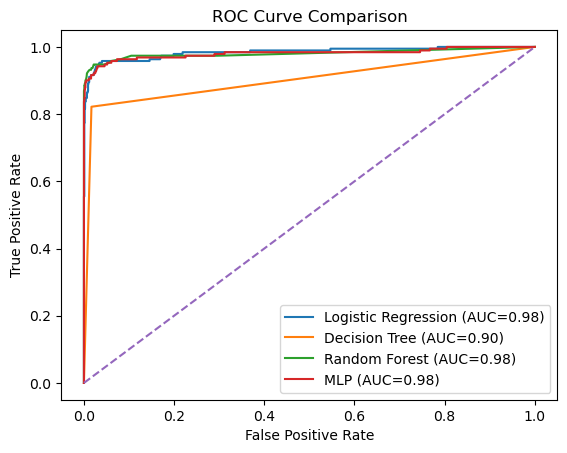

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probability predictions
prob_LR = LoR.predict_proba(X_test)[:,1]
prob_DT = DT.predict_proba(X_test)[:,1]
prob_RF = RF.predict_proba(X_test)[:,1]
prob_MLP = MLP.predict_proba(X_test)[:,1]

# ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_LR)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_DT)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_RF)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, prob_MLP)

# AUC scores
auc_lr = roc_auc_score(y_test, prob_LR)
auc_dt = roc_auc_score(y_test, prob_DT)
auc_rf = roc_auc_score(y_test, prob_RF)
auc_mlp = roc_auc_score(y_test, prob_MLP)

# Plot
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC={auc_mlp:.2f})')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### ROC Curve and AUC Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the performance of classification models by comparing the True Positive Rate (TPR) against the False Positive Rate (FPR) at different threshold values.

The Area Under the Curve (AUC) represents how well a model can distinguish between the two classes (spam and ham).
An AUC value closer to 1 indicates better classification performance.

From the ROC curve comparison:

Logistic Regression achieved an AUC of 0.98, indicating excellent discrimination between spam and ham messages.

Decision Tree achieved an AUC of 0.90, which is lower compared to the other models.

Random Forest achieved an AUC of 0.98, showing very strong classification capability.

MLP (Deep Neural Network) also achieved an AUC of 0.98, demonstrating high performance in detecting spam messages.

Overall, Logistic Regression, Random Forest, and MLP show very strong performance, while Decision Tree performs comparatively weaker.

The dashed diagonal line in the plot represents a random classifier, and all models perform significantly better than this baseline.

### Final Model Selection

To determine the best model for the SMS Spam Detection system, several factors were considered:

Accuracy

Precision

Recall

F1-Score

ROC Curve

AUC Score

Parameter Count

Computational Cost (MAC Values)

These metrics help evaluate both the prediction performance and the computational efficiency of each model.

### Performance Summary

| Model                     | Accuracy | Spam Precision | Spam Recall | Spam F1  | AUC      | Parameter Count | MAC Value  |
| ------------------------- | -------- | -------------- | ----------- | -------- | -------- | --------------- | ---------- |
| Logistic Regression       | 0.96     | 0.99           | 0.74        | 0.85     | 0.98     | 7,399           | 7,398      |
| Decision Tree             | 0.96     | 0.87           | 0.84        | 0.85     | 0.90     | 179             | 318,114    |
| Random Forest             | 0.97     | 1.00           | 0.81        | 0.89     | 0.98     | 55,678          | 31,811,400 |
| MLP (Deep Neural Network) | **0.98** | 0.99           | **0.85**    | **0.92** | **0.98** | 957,441         | 957,216    |

### Analysis

MLP (Deep Neural Network) achieved the highest accuracy (98%) and the best F1-score (0.92), indicating strong overall classification performance.

It also maintained a high AUC score (0.98), showing excellent ability to distinguish between spam and ham messages.

Random Forest provided strong performance but had the highest computational cost due to multiple decision trees.

Logistic Regression had the lowest computational cost and parameter count, making it the most efficient but slightly less effective in spam detection.

Decision Tree had moderate performance but lower AUC compared to the other models.

Final Decision

Considering all evaluation metrics and model complexity, the MLP (Deep Neural Network) is selected as the best overall model for the SMS Spam Detection system.

It provides the best balance between predictive performance and computational efficiency, making it the most effective model for detecting spam messages in this project.